### Imports

In [1]:
import torch
import numpy as np
from src.preprocessing.sort_tec_data import build_sorted_dataset
from src.preprocessing.dataset import prepare_dataset
from src.configs.config import (
    BASE_DIR_1, OUTPUT_DIR_1, BASE_DIR_2, OUTPUT_DIR_2,
    F_L1, F_L2, F_L5
)
from src.training.lstm_training import train_lstm
from src.training.transformer_training import train_transformer

from src.plots.loss_plots import (
    plot_lstm_loss, plot_transformer_loss,
)
from src.plots.prediction_plots import (
    plot_lstm_prediction, plot_transformer_prediction
)
from src.plots.delay_plots import (
    plot_diurnal_profile,
    plot_lstm_delay,
    plot_transformer_delay
)
from src.utils.iono_delay import delay_metrics, tec_to_iono_delay
from src.utils.save_results import save_delay_csv

---
# DATASET 1
---

### 1. BASE DIRECTORY AND OUTPUT DIRECTORY — Dataset 1

In [2]:
print(f"Base directory 1  : {BASE_DIR_1}")
print(f"Output directory 1: {OUTPUT_DIR_1}")

Base directory 1  : d:\Projects\ionospheric-tec-forecasting\DataSet\DataSet1
Output directory 1: d:\Projects\ionospheric-tec-forecasting\DataSet\DataSet1\sortedDataSet


### 2. CREATING SORTED DATASET — Dataset 1
```text
Process folders iisc1290_TECU to iisc1690_TECU and create one sorted CSV
per folder containing the maximum TEC value for each minute.
Returns: Number of output CSV files written.
```

In [3]:
written_files_1 = build_sorted_dataset(1)

print("TEC data sorting completed — Dataset 1.")
print(f"Number of output CSV files written: {written_files_1}")
print(f"Saved sorted CSV files to: {OUTPUT_DIR_1}")

TEC data sorting completed — Dataset 1.
Number of output CSV files written: 41
Saved sorted CSV files to: d:\Projects\ionospheric-tec-forecasting\DataSet\DataSet1\sortedDataSet


#### QUICK SANITY CHECK — Dataset 1
> Print first 6 lines of the first output file

In [4]:
sample_file = OUTPUT_DIR_1 / "iisc1290_TECU_sorted.csv"
if sample_file.exists():
    with sample_file.open("r", newline="", encoding="utf-8") as f:
        for i, line in enumerate(f):
            print(line.strip())
            if i >= 5:
                break
else:
    print(f"Sample file not found: {sample_file}")

Time(UTC),TEC(TECU)
09-05-23 00:00,42.390972
09-05-23 00:01,51.206161
09-05-23 00:02,32.852289
09-05-23 00:03,34.870453
09-05-23 00:04,39.373245


### 3. LOAD & PREPROCESS — Dataset 1
```text
Loads sorted CSVs into a (days × minutes) numpy matrix,
builds supervised input/target pairs, and
normalises using training stats only.
```

In [5]:
X_train_1, y_train_1, X_val_1, y_val_1, stats_1, daily_matrix_1, daily_files_1 = prepare_dataset(1)

print(f"X_train : {X_train_1.shape}   y_train : {y_train_1.shape}")
print(f"X_val   : {X_val_1.shape}     y_val   : {y_val_1.shape}")
print(f"Norm stats : {stats_1}")

X_train : (29, 1440, 1)   y_train : (29, 1440, 1)
X_val   : (11, 1440, 1)     y_val   : (11, 1440, 1)
Norm stats : {'x_mean': 87.88667297363281, 'x_std': 45.894798288808595, 'y_mean': 86.92459106445312, 'y_std': 45.30130768822266}


### 4. TRAIN LSTM — Dataset 1

> Dataset consists of 41 chronologically sorted TEC files.

```text
Training Set
------------
Input  : Days  1-29
Target : Days  2-30

Validation Set
--------------
Input  : Days 30-40
Target : Days 31-41

Forecast
--------
Input  : Day 40
Output : Day 41
```

In [6]:
lstm_model_1, lstm_history_1 = train_lstm(X_train_1, y_train_1, X_val_1, y_val_1)

Epoch 1/50 — loss: 0.970071 — val_loss: 0.703141
Epoch 2/50 — loss: 0.796376 — val_loss: 0.484105
Epoch 3/50 — loss: 0.379775 — val_loss: 0.139985
Epoch 4/50 — loss: 0.206873 — val_loss: 0.170383
Epoch 5/50 — loss: 0.157360 — val_loss: 0.136358
Epoch 6/50 — loss: 0.162006 — val_loss: 0.129844
Epoch 7/50 — loss: 0.146071 — val_loss: 0.134694
Epoch 8/50 — loss: 0.148146 — val_loss: 0.128769
Epoch 9/50 — loss: 0.141884 — val_loss: 0.126743
Epoch 10/50 — loss: 0.142981 — val_loss: 0.124715
Epoch 11/50 — loss: 0.134841 — val_loss: 0.125377
Epoch 12/50 — loss: 0.138120 — val_loss: 0.117390
Epoch 13/50 — loss: 0.129662 — val_loss: 0.117523
Epoch 14/50 — loss: 0.130526 — val_loss: 0.114831
Epoch 15/50 — loss: 0.134959 — val_loss: 0.116569
Epoch 16/50 — loss: 0.126524 — val_loss: 0.116000
Epoch 17/50 — loss: 0.135709 — val_loss: 0.118328
Epoch 18/50 — loss: 0.125984 — val_loss: 0.119945
Epoch 19/50 — loss: 0.124353 — val_loss: 0.115734
Epoch 20/50 — loss: 0.129371 — val_loss: 0.115576
Epoch 21/

### 5. LSTM LOSS vs VALIDATION PLOT — Dataset 1

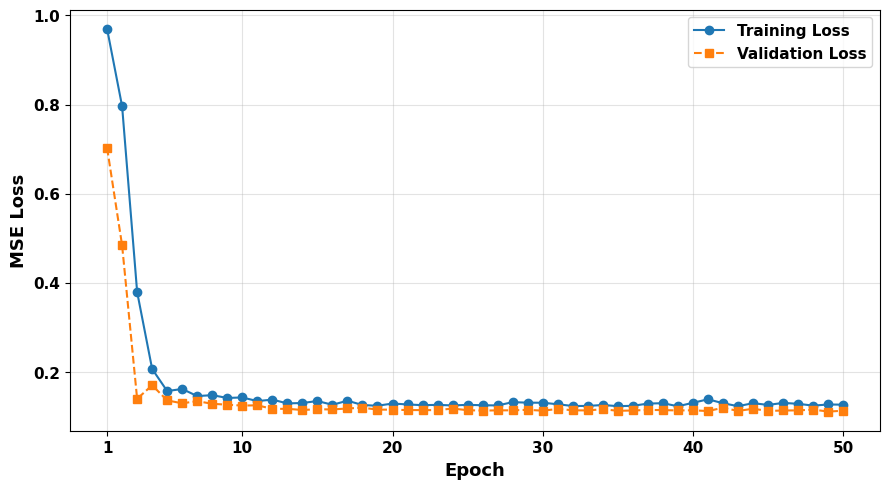

Final train loss : 0.126803
Final val   loss : 0.113233


In [7]:
plot_lstm_loss(lstm_history_1)

### 6. LSTM Day-41 PREDICTION — Dataset 1

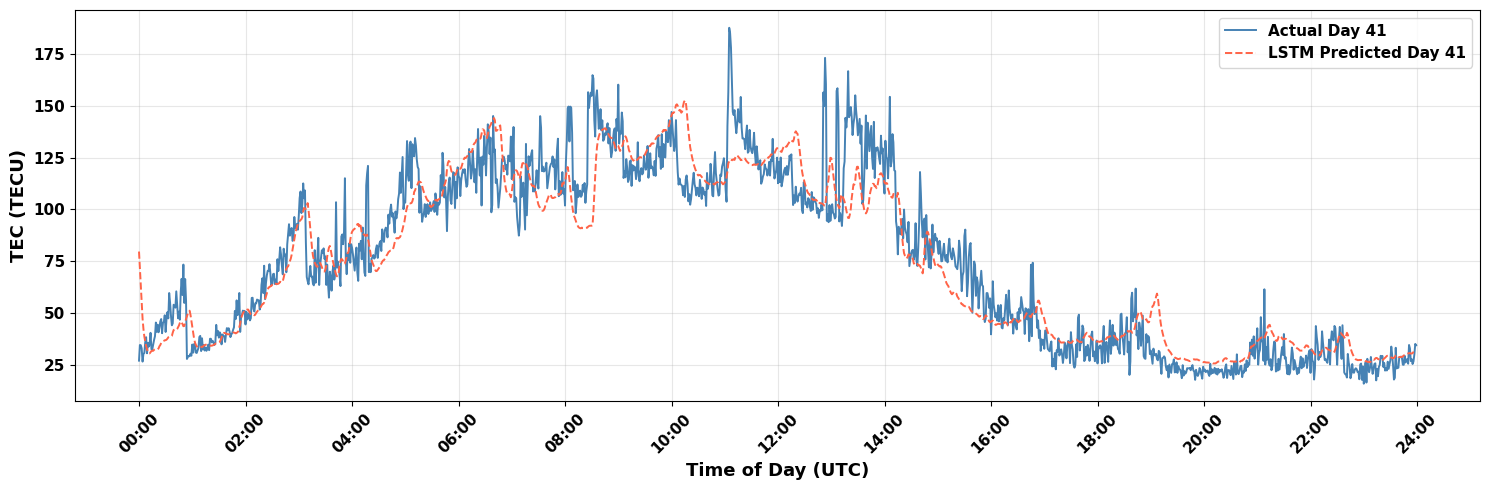

LSTM  Day-41 RMSE : 15.3465 TECU
LSTM  Day-41 MAE  : 11.0779 TECU


In [8]:
x_mean_1, x_std_1 = stats_1["x_mean"], stats_1["x_std"]
y_mean_1, y_std_1 = stats_1["y_mean"], stats_1["y_std"]

day40_raw_1 = daily_matrix_1[39]
actual41_1  = daily_matrix_1[40]

day40_in_1 = ((day40_raw_1 - x_mean_1) / x_std_1)[np.newaxis, ..., np.newaxis]   # (1, 1440, 1)

device = next(lstm_model_1.parameters()).device
src    = torch.tensor(day40_in_1, dtype=torch.float32).to(device)

lstm_model_1.eval()
with torch.no_grad():
    pred41_norm_1 = lstm_model_1(src).squeeze().cpu().numpy()   # (1440,)

lstm_pred41_1 = pred41_norm_1 * y_std_1 + y_mean_1

lstm_rmse_1, lstm_mae_1 = plot_lstm_prediction(actual41_1, lstm_pred41_1)

### 7. TRAIN TRANSFORMER — Dataset 1

In [ ]:
transformer_model_1, transformer_history_1 = train_transformer(X_train_1, y_train_1, X_val_1, y_val_1)

[Transformer] Training on: cpu


d:\Projects\ionospheric-tec-forecasting\src\models\transformer_model.py:101: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


TECTransformerEncoder(
  (input_proj): Linear(in_features=1, out_features=64, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
    (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
  )
  (output_proj): Linear(in_features=64, out_features=1, bias=True)
)
Ep

### 8. TRANSFORMER LOSS vs VALIDATION PLOT — Dataset 1

In [ ]:
plot_transformer_loss(transformer_history_1)

### 9. TRANSFORMER Day-41 PREDICTION — Dataset 1

In [ ]:
day40_in_t_1 = ((day40_raw_1 - x_mean_1) / x_std_1)[np.newaxis, ..., np.newaxis]   # (1, 1440, 1)

device  = next(transformer_model_1.parameters()).device
src_t_1 = torch.tensor(day40_in_t_1, dtype=torch.float32).to(device)

transformer_model_1.eval()
with torch.no_grad():
    trans_pred41_norm_1 = transformer_model_1(src_t_1).squeeze().cpu().numpy()   # (1440,)

trans_pred41_1 = trans_pred41_norm_1 * y_std_1 + y_mean_1

trans_rmse_1, trans_mae_1 = plot_transformer_prediction(actual41_1, trans_pred41_1)

### 10. MODEL COMPARISON SUMMARY — Dataset 1

In [ ]:
print("=" * 45)
print(f"{'Model':<15} {'RMSE (TECU)':>12} {'MAE (TECU)':>12}")
print("-" * 45)
print(f"{'LSTM':<15} {lstm_rmse_1:>12.4f} {lstm_mae_1:>12.4f}")
print(f"{'Transformer':<15} {trans_rmse_1:>12.4f} {trans_mae_1:>12.4f}")
print("=" * 45)

### 11. IONOSPHERIC DELAY — LSTM — Dataset 1
```text
F_L1 = 1575.42e6 Hz
F_L2 = 1227.60e6 Hz
F_L5 = 1176.45e6 Hz
```

In [ ]:
plot_lstm_delay(actual41_1, lstm_pred41_1, freq=F_L1)

In [ ]:
plot_lstm_delay(actual41_1, lstm_pred41_1, freq=F_L2)

In [ ]:
plot_lstm_delay(actual41_1, lstm_pred41_1, freq=F_L5)

### 12. IONOSPHERIC DELAY — TRANSFORMER — Dataset 1
```text
F_L1 = 1575.42e6 Hz
F_L2 = 1227.60e6 Hz
F_L5 = 1176.45e6 Hz
```

In [ ]:
plot_transformer_delay(actual41_1, trans_pred41_1, freq=F_L1)

In [ ]:
plot_transformer_delay(actual41_1, trans_pred41_1, freq=F_L2)

In [ ]:
plot_transformer_delay(actual41_1, trans_pred41_1, freq=F_L5)

### 13. DIURNAL HOURLY PROFILE — Dataset 1

In [ ]:
plot_diurnal_profile(actual41_1, lstm_pred41_1, trans_pred41_1, frequency=F_L1)

### 14. DELAY ERROR METRICS — Dataset 1

In [ ]:
iono_actual41_1 = tec_to_iono_delay(actual41_1)
iono_lstm41_1   = tec_to_iono_delay(lstm_pred41_1)
iono_trans41_1  = tec_to_iono_delay(trans_pred41_1)

print("Ionospheric Delay Error (L1, vertical) — Day 41 — Dataset 1")
print("=" * 62)
delay_metrics("LSTM",        iono_lstm41_1,  iono_actual41_1)
delay_metrics("Transformer", iono_trans41_1, iono_actual41_1)

### 15. SAVE OUTPUT CSV — Dataset 1

In [ ]:
save_delay_csv(actual41_1, lstm_pred41_1, trans_pred41_1, output_dir=OUTPUT_DIR_1)

---
# DATASET 2
---

### 16. BASE DIRECTORY AND OUTPUT DIRECTORY — Dataset 2

In [ ]:
print(f"Base directory 2  : {BASE_DIR_2}")
print(f"Output directory 2: {OUTPUT_DIR_2}")

### 17. CREATING SORTED DATASET — Dataset 2
```text
Process folders iisc0910_TECU to iisc1310_TECU and create one sorted CSV
per folder containing the maximum TEC value for each minute.
Returns: Number of output CSV files written.
```

In [ ]:
written_files_2 = build_sorted_dataset(2)

print("TEC data sorting completed — Dataset 2.")
print(f"Number of output CSV files written: {written_files_2}")
print(f"Saved sorted CSV files to: {OUTPUT_DIR_2}")

#### QUICK SANITY CHECK — Dataset 2
> Print first 6 lines of the first output file

In [ ]:
sample_file_2 = OUTPUT_DIR_2 / "iisc0910_TECU_sorted.csv"
if sample_file_2.exists():
    with sample_file_2.open("r", newline="", encoding="utf-8") as f:
        for i, line in enumerate(f):
            print(line.strip())
            if i >= 5:
                break
else:
    print(f"Sample file not found: {sample_file_2}")

### 18. LOAD & PREPROCESS — Dataset 2
```text
Loads sorted CSVs into a (days × minutes) numpy matrix,
builds supervised input/target pairs, and
normalises using training stats only.
```

In [ ]:
X_train_2, y_train_2, X_val_2, y_val_2, stats_2, daily_matrix_2, daily_files_2 = prepare_dataset(2)

print(f"X_train : {X_train_2.shape}   y_train : {y_train_2.shape}")
print(f"X_val   : {X_val_2.shape}     y_val   : {y_val_2.shape}")
print(f"Norm stats : {stats_2}")

### 19. TRAIN LSTM — Dataset 2

> Dataset consists of 41 chronologically sorted TEC files.

```text
Training Set
------------
Input  : Days  1-29
Target : Days  2-30

Validation Set
--------------
Input  : Days 30-40
Target : Days 31-41

Forecast
--------
Input  : Day 40
Output : Day 41
```

In [ ]:
lstm_model_2, lstm_history_2 = train_lstm(X_train_2, y_train_2, X_val_2, y_val_2)

### 20. LSTM LOSS vs VALIDATION PLOT — Dataset 2

In [ ]:
plot_lstm_loss(lstm_history_2)

### 21a. LSTM Day-40 PREDICTION — Dataset 2


In [ ]:
x_mean_2, x_std_2 = stats_2["x_mean"], stats_2["x_std"]
y_mean_2, y_std_2 = stats_2["y_mean"], stats_2["y_std"]

day39_raw_2 = daily_matrix_2[38]
actual40_2  = daily_matrix_2[39]

day39_in_2 = ((day39_raw_2 - x_mean_2) / x_std_2)[np.newaxis, ..., np.newaxis]   # (1, 1440, 1)

device = next(lstm_model_2.parameters()).device
src39  = torch.tensor(day39_in_2, dtype=torch.float32).to(device)

lstm_model_2.eval()
with torch.no_grad():
    pred40_norm_2 = lstm_model_2(src39).squeeze().cpu().numpy()   # (1440,)

lstm_pred40_2 = pred40_norm_2 * y_std_2 + y_mean_2

# derive label automatically from the loaded files
label_40_2 = f"Actual Day 40 ({daily_files_2[-2].stem.replace('_sorted', '')})"  # -> "Actual Day 40 (iisc1300_TECU)"

lstm_rmse_40_2, lstm_mae_40_2 = plot_lstm_prediction(actual40_2, lstm_pred40_2, actual_label=label_40_2, target_day=40)


### 21b. LSTM Day-41 PREDICTION — Dataset 2


In [ ]:
day40_raw_2 = daily_matrix_2[39]
actual41_2  = daily_matrix_2[40]

day40_in_2 = ((day40_raw_2 - x_mean_2) / x_std_2)[np.newaxis, ..., np.newaxis]   # (1, 1440, 1)

device = next(lstm_model_2.parameters()).device
src    = torch.tensor(day40_in_2, dtype=torch.float32).to(device)

lstm_model_2.eval()
with torch.no_grad():
    pred41_norm_2 = lstm_model_2(src).squeeze().cpu().numpy()   # (1440,)

lstm_pred41_2 = pred41_norm_2 * y_std_2 + y_mean_2

# derive label automatically from the loaded files
label_2 = f"Actual Day 41 ({daily_files_2[-1].stem.replace('_sorted', '')})"  # -> "Actual Day 41 (iisc1310_TECU)"

lstm_rmse_2, lstm_mae_2 = plot_lstm_prediction(actual41_2, lstm_pred41_2, actual_label=label_2)


### 22. TRAIN TRANSFORMER — Dataset 2

In [ ]:
transformer_model_2, transformer_history_2 = train_transformer(X_train_2, y_train_2, X_val_2, y_val_2)

### 23. TRANSFORMER LOSS vs VALIDATION PLOT — Dataset 2

In [ ]:
plot_transformer_loss(transformer_history_2)

### 24a. TRANSFORMER Day-40 PREDICTION — Dataset 2

In [ ]:
day39_in_t_2 = ((day39_raw_2 - x_mean_2) / x_std_2)[np.newaxis, ..., np.newaxis]   # (1, 1440, 1)

device   = next(transformer_model_2.parameters()).device
src39_t  = torch.tensor(day39_in_t_2, dtype=torch.float32).to(device)

transformer_model_2.eval()
with torch.no_grad():
    trans_pred40_norm_2 = transformer_model_2(src39_t).squeeze().cpu().numpy()   # (1440,)

trans_pred40_2 = trans_pred40_norm_2 * y_std_2 + y_mean_2
trans_rmse_40_2, trans_mae_40_2 = plot_transformer_prediction(actual40_2, trans_pred40_2, actual_label=label_40_2, target_day=40)


### 24b. TRANSFORMER Day-41 PREDICTION — Dataset 2

In [ ]:
day40_in_t_2 = ((day40_raw_2 - x_mean_2) / x_std_2)[np.newaxis, ..., np.newaxis]   # (1, 1440, 1)

device  = next(transformer_model_2.parameters()).device
src_t_2 = torch.tensor(day40_in_t_2, dtype=torch.float32).to(device)

transformer_model_2.eval()
with torch.no_grad():
    trans_pred41_norm_2 = transformer_model_2(src_t_2).squeeze().cpu().numpy()   # (1440,)

trans_pred41_2 = trans_pred41_norm_2 * y_std_2 + y_mean_2
trans_rmse_2, trans_mae_2 =  plot_transformer_prediction(actual41_2, trans_pred41_2, actual_label=label_2)

### 25. MODEL COMPARISON SUMMARY — Dataset 2

In [ ]:
print("=" * 60)
print(f"{'Model':<15} {'Target Day':<12} {'RMSE (TECU)':>12} {'MAE (TECU)':>12}")
print("-" * 60)
print(f"{'LSTM':<15} {'Day 40':<12} {lstm_rmse_40_2:>12.4f} {lstm_mae_40_2:>12.4f}")
print(f"{'Transformer':<15} {'Day 40':<12} {trans_rmse_40_2:>12.4f} {trans_mae_40_2:>12.4f}")
print("-" * 60)
print(f"{'LSTM':<15} {'Day 41':<12} {lstm_rmse_2:>12.4f} {lstm_mae_2:>12.4f}")
print(f"{'Transformer':<15} {'Day 41':<12} {trans_rmse_2:>12.4f} {trans_mae_2:>12.4f}")
print("=" * 60)


### 26a. IONOSPHERIC DELAY — LSTM — Dataset 2 (DAY40)
```text
F_L1 = 1575.42e6 Hz
F_L2 = 1227.60e6 Hz
F_L5 = 1176.45e6 Hz
```


In [ ]:
plot_lstm_delay(actual40_2, lstm_pred40_2, freq=F_L1)

In [ ]:
plot_lstm_delay(actual40_2, lstm_pred40_2, freq=F_L2)

In [ ]:
plot_lstm_delay(actual40_2, lstm_pred40_2, freq=F_L5)

### 26b. IONOSPHERIC DELAY — TRANSFORMER — Dataset 2 (DAY40)
```text
F_L1 = 1575.42e6 Hz
F_L2 = 1227.60e6 Hz
F_L5 = 1176.45e6 Hz
```


In [ ]:
plot_transformer_delay(actual40_2, trans_pred40_2, freq=F_L1)

In [ ]:
plot_transformer_delay(actual40_2, trans_pred40_2, freq=F_L2)

In [ ]:
plot_transformer_delay(actual40_2, trans_pred40_2, freq=F_L5)

### 27a. IONOSPHERIC DELAY — LSTM — Dataset 2 (DAY41)
```text
F_L1 = 1575.42e6 Hz
F_L2 = 1227.60e6 Hz
F_L5 = 1176.45e6 Hz
```


In [ ]:
plot_lstm_delay(actual41_2, lstm_pred41_2, freq=F_L1)

In [ ]:
plot_lstm_delay(actual41_2, lstm_pred41_2, freq=F_L2)

In [ ]:
plot_lstm_delay(actual41_2, lstm_pred41_2, freq=F_L5)

### 27b. IONOSPHERIC DELAY — TRANSFORMER — Dataset 2 (DAY41)
```text
F_L1 = 1575.42e6 Hz
F_L2 = 1227.60e6 Hz
F_L5 = 1176.45e6 Hz
```


In [ ]:
plot_transformer_delay(actual41_2, trans_pred41_2, freq=F_L1)

In [ ]:
plot_transformer_delay(actual41_2, trans_pred41_2, freq=F_L2)

In [ ]:
plot_transformer_delay(actual41_2, trans_pred41_2, freq=F_L5)

### 28a. DIURNAL HOURLY PROFILE — Day 40 — Dataset 2

In [ ]:
plot_diurnal_profile(actual40_2, lstm_pred40_2, trans_pred40_2, frequency=F_L1)

### 28b. DIURNAL HOURLY PROFILE — Day 41 — Dataset 2


In [ ]:
plot_diurnal_profile(actual41_2, lstm_pred41_2, trans_pred41_2, frequency=F_L1)

### 29. DELAY ERROR METRICS — Dataset 2

In [ ]:
iono_actual41_2 = tec_to_iono_delay(actual41_2)
iono_lstm41_2   = tec_to_iono_delay(lstm_pred41_2)
iono_trans41_2  = tec_to_iono_delay(trans_pred41_2)

iono_actual40_2 = tec_to_iono_delay(actual40_2)
iono_lstm40_2   = tec_to_iono_delay(lstm_pred40_2)
iono_trans40_2  = tec_to_iono_delay(trans_pred40_2)

print("Ionospheric Delay Error (L1, vertical) — Day 40 — Dataset 2")
print("=" * 62)
delay_metrics("LSTM",        iono_lstm40_2,  iono_actual40_2)
delay_metrics("Transformer", iono_trans40_2, iono_actual40_2)

print()
print("Ionospheric Delay Error (L1, vertical) — Day 41 — Dataset 2")
print("=" * 62)
delay_metrics("LSTM",        iono_lstm41_2,  iono_actual41_2)
delay_metrics("Transformer", iono_trans41_2, iono_actual41_2)


### 30a. SAVE OUTPUT CSV — Day 40 — Dataset 2

In [ ]:
save_delay_csv(actual40_2, lstm_pred40_2, trans_pred40_2, output_dir=OUTPUT_DIR_2, filename="day40_ionospheric_delay.csv")

### 30b. SAVE OUTPUT CSV — Day 41 — Dataset 2


In [ ]:
save_delay_csv(actual41_2, lstm_pred41_2, trans_pred41_2, output_dir=OUTPUT_DIR_2, filename="day41_ionospheric_delay.csv")